In the following discussion, we will equate a Pokemon with its type, stats, and four known moves.  There's more to it, of course, but this seems like a good place to start.

# To Dos
- Solve the forme issue regarding stats

# The Problem

A pokemon's type, stats, and four known moves gives 12 dimensions of information about that pokemon.  While Player 1 win probability should be a nondecreasing function of the numeric stats, the amount of benefit provided from increasing a stat by one point depends on the matchup.  If you replace Weavile by Chien-Pao, your win probability should go up!  But how much it goes up should depend on the matchup.  If your opponent has no pokemon between Weavile's base 125 speed and Chien-Pao's base 135 speed, then your win probability shouldn't go up by very much.  Or, if your oppenent has lots of pokemon with high physical defense, then Chien-Pao's power increase (coming from its ability, not its stats) may not make much of a difference either.  But if your opponent has Eternatus (base speed 130), then replacing Weavile by Chien-Pao should make a big difference!  So a statistic's contribution to win probability is matchup dependent, and this seems hard for a model to learn.

Another issue is that for nearly every pokemon (maybe we should quantify this claim), their secondary attacking stat is irrelevant.  It does not matter what your Chien-Pao's special attack stat is; it will not affect the battle at all.  So when we're training a model, the model should not be told Chien-Pao's special attack stat.  One possibility is to replace every pokemon's attack and special attack stat with offensive_stat = max(atk, spa) and record a boolean offensive_stat_is_phys.  This is okay, but it seems like the model might have a hard time learning that if offensive_stat_is_phys == True, then offensive_stat should be compared with its opponents def stats, not spd stats.

Yet another issue is that the model will have to somehow divine the type chart from these battle outcomes.  This isn't a situation where having more Psychic types is better than having fewer; once again, it's matchup-dependent.

# A Solution

Rather than giving the model a bunch of basic information (types, stats, known moves) and hoping that the model learns the stuff we already know (Fire > Grass > Water > Fire), let's tell the model the stuff that we already know.  But how do you feed in the type chart and whatnot into the model?  Seems hard.

Instead, let's bake all of our knowledge into a set of offensive and defensive stats (we'll call these "advantage" stats) that are derived for each specific battle.  Then, we'll replace the basic stats with these "advantage" stats.

We will start off by neglecting the movepool.  We could try to map each move to its category, type, and base power, but that could be a lot of work.  It's something to explore in the future.

## Damage Approximator

The advantage stat starts with an approximation of damage.  Given a pokemon mon1 on team 1 and a pokemon mon2 on team 2, we can estimate the average damage that mon1 would do to mon2 by selecting its best STAB move (or a not-very-effective coverage move in the event that is better--this could be updated if we get data suggesting that in the event that a mon's best move is a coverage move, the coverage move is often neutral or better).  Note that we assume a base power of 80 for all moves.

We approximate that when mon1 attacks mon2, mon2 will lose the following fraction of its HP:

$$\text{damage}(\text{mon1},\text{mon2}) := \left(\frac{\left(\frac{2 \cdot \text{mon1}_{\text{level}}}{5} + 2\right) \cdot 80 \cdot \frac{\text{mon1}_{\text{off-stat}}}{\text{mon2}_{\text{def-stat}}}}{50} + 2\right) \cdot \text{type-multiplier}(\text{mon1},\text{mon2}) \cdot 92.5/100 / \text{mon2}_{\text{hp}}$$

where 

$$\text{mon1}_{\text{off-stat}} = \max(\text{mon1}_{\text{atk}}, \text{mon1}_{\text{spa}}),$$

$$ \text{mon2}_{\text{def-stat}} = \begin{cases} \text{mon2}_{\text{def}} & \text{if } \text{mon1}_{\text{off-stat}} = \text{mon1}_{\text{atk}} \\ \text{mon2}_{\text{spd}} & \text{else} \end{cases}, $$

$$ \text{type-multiplier}(\text{mon1},\text{mon2}) = \max\left(\frac{1}{2}, \max_{\text{type1} \in \text{mon1}_{\text{types}}} 1.5 \cdot \prod_{\text{type2} \in \text{mon2}_{\text{types}}} \text{eff}(\text{type1},\text{type2})\right) $$

with $\text{eff}(\text{type1},\text{type2})$ being determined by the type chart, so that, e.g. $\text{eff}(\text{water},\text{fire}) = 2$ while $\text{eff}(\text{fire},\text{water}) = 1/2$.

Some notes:
- This fraction is allowed to exceed 1 as the amount by which it exceeds 1 may actually matter (think: reflect/light screen/aurora veil or resistance berries).
- This uses a simplified version of the damage formula found here: https://bulbapedia.bulbagarden.net/wiki/Damage#Generation_V_onward
- The number 80 corresponds to the base power of the move theoretically being selected.
- The use of 92.5/100 corresponds to the average value of the 'random' factor.
- The use of type-multiplier is meant to approximate the product of STAB and Type.
- type-multiplier assumes that mon1 is only using STABs.  This could be updated to account for coverage moves in a future iteration on this stat.
- The max(1/2, stuff) in type-multiplier is to prevent type-multiplier from ever being 0.  It is very rare (though it does happen) that mon1 will be unable to damage mon2.  The factor of 1/2 is used because that is a multiplier for a not-very-effective coverage move.  This would be resolved by replacing the max over mon1 types by a max over mon1 move types.
- Damage or speed boosting items will not be accounted for.  This could be resolved in an ad-hoc way by checking for common boosting items (choice items, life orb).  It could also be resolved in a systemic way be using the smogon damage calculator to replace the offensive advantage stat.
- Damage/stat modifying abilities like Levitate, Thick Fat, or Sword of Ruin will not be accounted for.  This could 'only' be resolved by using the smogon damage calculator to replace this offensive advantage stat.
- Type chart modifying moves like Freeze-Dry are not accounted for.


## Advantage

The only (relevant) thing that doesn't go into the damage approximator is speed.  Speed is difficult to incorporate into advantage.  There are a few reasons for this:
  1. The only important feature of speed differential (meaning $\text{mon1}_{\text{spe}} - \text{mon2}_{\text{spe}}$) is its sign.  Magnitude is meaningless here.  So multiplying the damage approximation by speed differential would be a bad idea.
  2. The impact of speed differential can be large or small.  If you consider a hypothetical Weavile versus Iron Boulder matchup, each has a super-effective STAB on the other (meaning it has a type-multiplier equal to 3)!  In that situation, Weavile has the advantage because it goes first.  However, if you consider a Weavile versus Swampert matchup (where each has a type-multiplier of 1.5), the Swampert has the advantage in spite of its speed disadvantage due to its overall bulk.  My initial thought is that speed matters a lot when both pokemon are doing about the same amount of damage to one another, but doesn't matter very much when the pokemon are doing very different amounts of damage.  So 'having a speed advantage' should not correspond to a constant factor.

Also worth noting is that advantage depends not just on how much damage you're doing to your opponent, but how much damage your opponent is doing to you!

Maybe try computing 'turns to KO' for each mon and look at differential.  So we get something like

$$ \text{time-to-ko-diff}(\text{mon1},\text{mon2}) = \lceil \frac{1}{\min(1,\text{damage-approx}(\text{mon2},\text{mon1}))}\rceil - \lceil\frac{1}{\min(1,\text{damage-approx}(\text{mon1},\text{mon2}))}\rceil $$

Here, bigger is better for mon1.

Properties that I want:
- There should be a nice relationship between adv(mon1,mon2) and adv(mon2,mon1) (a + b = 1 with 0 < a,b < 1?  ab = 1?)
- If time-to-ko-diff is close to 0 and the times to ko are close to 1, the faster mon should have a big advantage (this is the situation where the faster mon just OHKOs the slower mon with no cost)
- If the time-to-ko-diff is close to 0 and the times to ko are large, the faster mon should have a small advantage (this is the situation where the faster mon KOs the slower mon but at an HP cost)
- If the time-to-ko-diff is large, the mon with the smaller time to ko should have a big advantage (this is the situation where one mon just dominates the other)

So maybe the advantage stat should represent something like: expected damage dealt to opponent in a 1v1 matchup?  If we let $n$ denote the round number in which the KO occurs, then the faster mon gets to go $n$ times and the slower mon gets to go $n$ or $n-1$ times depending on who wins.

Let's set

$$\text{time-to-ko}(\text{mon1},\text{mon2}) = \lceil \frac{1}{\min(1,\text{damage-approx}(\text{mon1},\text{mon2}))} \rceil$$

Then

$$\text{turn-of-ko}(\text{mon1},\text{mon2}) = \min\left(\text{time-to-ko}(\text{mon1},\text{mon2}), \text{time-to-ko}(\text{mon2},\text{mon1})\right)$$

So

$$
\text{1v1-damage}(\text{mon1},\text{mon2}) =
\begin{cases}
    (\text{turn-of-ko}(\text{mon1},\text{mon2}) - 1) \cdot \text{damage-approx}(\text{mon1},\text{mon2})  &\text{if } \text{mon1}_{\text{spe}} < \text{mon2}_{\text{spe}} \text{ and mon2 KOs mon1}\\
    \text{turn-of-ko}(\text{mon1},\text{mon2}) \cdot \text{damage-approx}(\text{mon1},\text{mon2})        &\text{else}
    
\end{cases}
$$

Then we can do something like set $\text{adv}(\text{mon1},\text{mon2}) = \text{1v1-damage}(\text{mon1},\text{mon2})$ or we can do something fancy and make it symmetric like $\text{adv}(\text{mon1},\text{mon2}) = \text{1v1-damage}(\text{mon1},\text{mon2}) - \text{1v1-damage}(\text{mon2},\text{mon1})$.

Regardless, this should be enough to get started.


## Potential problems with advantage stats

Some pokemon are not good because of their stats.  Take Sableye for example.  It has atrocious stats, but can win a match on the strength of its ability, Prankster.  These advantage stats won't account for that.  (On the other hand, neither will training on 12-dimensional info above.)

Other pokemon don't rely on their offensive stats for damage (think Toxapex).

Yet more pokemon rely heavily on priority moves.

# Testing

In order to test the FullPokemon class, we need:

- type_multiplier:
  - m1 has a 4x effective STAB (m1 = Weavile, m2 = Salamence)
  - m1 has a 2x effective STAB (m1 = Weavile, m2 = Haxorus)
  - m1's best STAB is neutral (m1 = Weavile, m2 = Corviknight)
  - m1's best STAB is 1/2x effective (m1 = Weavile, m2 = Chien-Pao)
  - m1's best STAB is 1/4x effective (m1 = Conkeldurr, m2 = Fezandipiti)
  - m1's best STAB is 0x effective (m1 = Banette, m2 = Wigglytuff)

- damage
  - already tested manually by comparing physical and special attackers on the calcs at calc.pokemonshowdown.com

- one_v_one_damage
  - m1 is faster than m2 and KOs m2 (m1 = Weavile, m2 = Salamence)
  - m2 is faster than m1 and KOs m1 (m1 = Sinistcha?, m2 = Weavile)
  - m1 is faster than m2 yet is KOd by m2 (m1 = Weavile, m2 = Conkeldurr)
  - m2 is faster than m1 yet is KOd by m1 (m1 = Swampert, m2 = Corviknight?)
  - m1 and m2 have a speed tie (m1 = Lanturn, m2 = Toxtricity)

In [1]:
import sys
import os
import json
import pandas as pd
from pathlib import Path
sys.path.insert(0,os.path.abspath('..'))
from tools import battle as b

In [2]:
desired_mon_names = ['Weavile','Salamence','Haxorus','Corviknight','Chien-Pao','Conkeldurr','Fezandipiti','Banette','Wigglytuff','Sinistcha','Swampert','Lanturn','Toxtricity']
log_dir = Path("../data/replays/gen9-randombattle")
desired_team_dict = {}
for file in log_dir.iterdir():
    if file.is_file():
        with open(file,"r") as battle_json:
            battle = json.load(battle_json)
        for mon in desired_mon_names:
            for team_index in range(2):
                if mon in battle["teams_full"][team_index].keys():
                    desired_team_dict[mon] = battle["teams_full"][team_index][mon]
                    desired_mon_names.remove(mon)
desired_team_dict

{'Lanturn': {'name': 'Lanturn',
  'species': 'Lanturn',
  'speciesId': 'lanturn',
  'gender': 'F',
  'shiny': False,
  'level': 89,
  'moves': ['scald', 'thunderbolt', 'thunderwave', 'icebeam'],
  'ability': 'Volt Absorb',
  'evs': {'hp': 85, 'atk': 0, 'def': 85, 'spa': 85, 'spd': 85, 'spe': 85},
  'ivs': {'hp': 31, 'atk': 0, 'def': 31, 'spa': 31, 'spd': 31, 'spe': 31},
  'item': 'Leftovers',
  'teraType': 'Flying',
  'role': 'Bulky Attacker',
  'bvs': {'hp': 125, 'atk': 58, 'def': 58, 'spa': 76, 'spd': 76, 'spe': 67},
  'stats': {'hp': 367,
   'atk': 108,
   'def': 154,
   'spa': 186,
   'spd': 186,
   'spe': 170},
  'types': ['Water', 'Electric']},
 'Haxorus': {'name': 'Haxorus',
  'species': 'Haxorus',
  'speciesId': 'haxorus',
  'gender': 'F',
  'shiny': False,
  'level': 77,
  'moves': ['dragondance', 'earthquake', 'outrage', 'ironhead'],
  'ability': 'Mold Breaker',
  'evs': {'hp': 85, 'atk': 85, 'def': 85, 'spa': 85, 'spd': 85, 'spe': 85},
  'ivs': {'hp': 31, 'atk': 31, 'def': 3

In [3]:
test_pokemon = {mon:b.FullPokemon(desired_team_dict[mon]) for mon in desired_team_dict.keys()}

In [4]:
print("Now testing type_multiplier")
assert(b.FullPokemon.type_multiplier(test_pokemon['Weavile'],test_pokemon['Salamence']) == 6),"Weavile and Salamence failed"
assert(b.FullPokemon.type_multiplier(test_pokemon['Weavile'],test_pokemon['Haxorus']) == 3), "Weavile and Haxorus failed"
assert(b.FullPokemon.type_multiplier(test_pokemon['Weavile'],test_pokemon['Corviknight']) == 1.5), "Weavile and Corviknight failed"
assert(b.FullPokemon.type_multiplier(test_pokemon['Weavile'],test_pokemon['Chien-Pao']) == 0.75), "Weavile and Chien-Pao failed"
assert(b.FullPokemon.type_multiplier(test_pokemon['Conkeldurr'],test_pokemon['Fezandipiti']) == 1/2), "Conkeldurr and Fezandipiti failed"
assert(b.FullPokemon.type_multiplier(test_pokemon['Banette'],test_pokemon['Wigglytuff']) == 1/2), "Banette and Wigglytuff failed"

print()
print("Now testing one_v_one_damage")
ovo = b.FullPokemon.one_v_one_damage(test_pokemon['Weavile'],test_pokemon['Salamence'])
assert(ovo[0] >= 1 and ovo[1] == 0), "Weavile and Salamence failed"
ovo = b.FullPokemon.one_v_one_damage(test_pokemon['Sinistcha'],test_pokemon['Weavile'])
assert(ovo[0] > 0 and ovo[0] < 1 and ovo[1] >= 1), "Sinistcha and Weavile failed"
ovo = b.FullPokemon.one_v_one_damage(test_pokemon['Weavile'],test_pokemon['Conkeldurr'])
assert(ovo[0] > 0 and ovo[0] < 1 and ovo[1] >=1),"Weavile and Conkeldurr failed"
ovo = b.FullPokemon.one_v_one_damage(test_pokemon['Swampert'],test_pokemon['Corviknight'])
assert(ovo[0] >= 1 and ovo[1] > 0 and ovo[1] < 1), "Swampert and Corviknight failed"
ovo = b.FullPokemon.one_v_one_damage(test_pokemon["Lanturn"],test_pokemon["Toxtricity"])
assert(ovo[0] >= 1 and ovo[1] >= 0.72 and ovo[1] < 1), "Lanturn and Toxtricity failed"

Now testing type_multiplier

Now testing one_v_one_damage


## Examples

In [5]:
id = "2631906096"
with open("../data/replays/gen9-randombattle/gen9randombattle-" + id + ".json","r") as battle_json:
    data = json.load(battle_json)

team1 = [b.FullPokemon(data["teams_full"][0][key]) for key in data["teams_full"][0].keys()]
team2 = [b.FullPokemon(data["teams_full"][1][key]) for key in data["teams_full"][1].keys()]
col_names = [f"adv_over_{mon2.name}" for mon2 in team2]
col_names.insert(0,"p1_mon")
rows = []
for i,mon1 in enumerate(team1):
    rows.append([b.FullPokemon.advantage(mon1,mon2) for mon2 in team2])
    rows[i].insert(0,mon1.name)
df = pd.DataFrame(rows,columns=col_names)
adv_matrix = [[b.FullPokemon.advantage(mon1,mon2) for mon2 in team2] for mon1 in team1]
sum(sum(adv_matrix[i]) for i in range(len(adv_matrix)))

4.815082462271961

In [6]:
df

,p1_mon,adv_over_Abomasnow,adv_over_Ceruledge,adv_over_Chansey,adv_over_Hippowdon,adv_over_Carbink,adv_over_Klefki
0,Quaquaval,0.715086,1.328708,1.100367,0.649726,-0.168379,-0.605830
1,Pecharunt,1.050588,0.624728,0.492110,-0.674954,-0.312160,0.255685
2,Noivern,-0.756319,0.257875,-0.347247,0.900206,-0.794214,-0.862681
3,Azumarill,-1.031641,-0.066877,-0.567092,0.680872,0.350973,-0.343552
4,Gogoat,-0.768560,-1.037238,1.039033,0.872012,0.853608,-0.258471
5,Klawf,1.121944,1.654554,1.111303,-0.789109,0.170756,-1.030727


In [7]:
[[f"{adv_matrix[i][j]:.2f}" for j in range(6)] for i in range(6)]

[['0.72', '1.33', '1.10', '0.65', '-0.17', '-0.61'],
 ['1.05', '0.62', '0.49', '-0.67', '-0.31', '0.26'],
 ['-0.76', '0.26', '-0.35', '0.90', '-0.79', '-0.86'],
 ['-1.03', '-0.07', '-0.57', '0.68', '0.35', '-0.34'],
 ['-0.77', '-1.04', '1.04', '0.87', '0.85', '-0.26'],
 ['1.12', '1.65', '1.11', '-0.79', '0.17', '-1.03']]

## EDA

In [8]:
import sys
import os
import json
import pandas as pd
import matplotlib as plt
import seaborn as sns
from pathlib import Path
sys.path.insert(0,os.path.abspath('..'))
from tools import battle as b
log_dir = Path("../data/replays/gen9-randombattle")
stat_names = ['hp','atk','def','spa','spd','spe']

In [9]:
rows = []
col_names = ['battle_id','p1_wins','elo_diff']
for i in range(6):
    for j in range(6):
        col_names.append(f"p1_m{i+1}_adv_over_p2_m{j+1}")
for file in log_dir.iterdir():
    if file.is_file():
        battle = b.Battle(file)
        if not battle.custom_ruleQ and not battle.end_time - battle.start_time < 60: # throw out battles with custom rules and those that last less than 60 seconds
            with open(file,"r") as battle_json:
                battle_data = json.load(battle_json)
            rows.append([battle_data["id"],int(battle.winner.name == battle.p1.name),battle.p1.elo0-battle.p2.elo0])
            team1 = [b.FullPokemon(battle_data["teams_full"][0][mon]) for mon in battle_data["teams_full"][0].keys()]
            team2 = [b.FullPokemon(battle_data["teams_full"][1][mon]) for mon in battle_data["teams_full"][1].keys()]
            for i in range(6):
                for j in range(6):
                    rows[-1].append(b.FullPokemon.advantage(team1[i],team2[j]))

match_data = pd.DataFrame(rows,columns=col_names)

In [10]:
match_data

,battle_id,p1_wins,elo_diff,p1_m1_adv_over_p2_m1,p1_m1_adv_over_p2_m2,p1_m1_adv_over_p2_m3,p1_m1_adv_over_p2_m4,p1_m1_adv_over_p2_m5,p1_m1_adv_over_p2_m6,p1_m2_adv_over_p2_m1,...,p1_m5_adv_over_p2_m3,p1_m5_adv_over_p2_m4,p1_m5_adv_over_p2_m5,p1_m5_adv_over_p2_m6,p1_m6_adv_over_p2_m1,p1_m6_adv_over_p2_m2,p1_m6_adv_over_p2_m3,p1_m6_adv_over_p2_m4,p1_m6_adv_over_p2_m5,p1_m6_adv_over_p2_m6
0,gen9randombattle-2631906096,0,-5,0.715086,1.328708,1.100367,0.649726,-0.168379,-0.605830,1.050588,...,1.039033,0.872012,0.853608,-0.258471,1.121944,1.654554,1.111303,-0.789109,0.170756,-1.030727
1,gen9randombattle-2631763570,0,10,-1.102343,-0.912040,-0.822721,0.397518,-0.967776,-1.095651,-0.166276,...,-0.498879,0.270978,-0.776190,-0.535428,0.476433,-0.809819,0.191290,0.357970,1.173952,1.035264
2,gen9randombattle-2631369343,1,-69,-1.108051,0.533011,1.163594,-0.392851,0.407047,1.024607,0.625551,...,-0.367578,0.743372,-1.148583,1.080020,1.005441,-1.007017,-0.120664,0.166639,0.305740,0.538460
3,gen9randombattle-2631529004,1,17,-0.173456,-0.971856,0.274374,-0.283311,0.510040,1.128905,-0.796007,...,0.212533,-0.519739,-1.129192,0.670411,1.063704,0.927443,0.942618,-0.156272,1.043459,0.814467
4,gen9randombattle-2631993792,0,58,-0.290351,0.339730,0.159254,-0.404944,-0.439897,-0.794229,0.800098,...,-1.295679,-0.469600,-0.618894,0.692243,1.033497,-0.499937,-0.197355,1.482827,0.203640,1.341519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4623,gen9randombattle-2631440114,1,41,0.466568,-0.332259,0.262304,1.282600,0.700100,-0.670539,-0.794315,...,0.961099,-1.040206,-0.575411,-0.390277,-0.284001,1.043605,0.934219,0.594527,1.647710,0.551990
4624,gen9randombattle-2631435014,0,-41,-0.338643,-1.068024,-0.313621,-0.768309,-0.505119,-0.287456,-0.622362,...,0.364622,-0.906603,-0.525597,0.401682,0.663443,-0.796316,0.647436,-0.761791,0.451214,-1.596547
4625,gen9randombattle-2632021860,1,119,-0.354663,1.171018,-0.593018,0.348115,0.725493,1.178656,0.703707,...,0.067488,-0.259890,0.345610,1.483343,0.576941,1.248727,-0.234713,0.226299,0.593333,-0.349652
4626,gen9randombattle-2631386449,1,-13,0.879972,0.764888,0.848133,0.908085,-0.515956,1.124624,0.894369,...,-0.296683,-0.722514,0.398275,0.357083,0.646008,0.733701,0.447504,0.663224,-0.223165,0.846311


<Axes: xlabel='elo_diff', ylabel='p1_wins'>

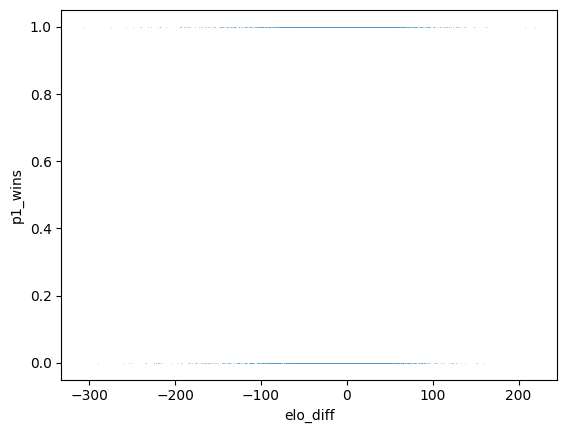

In [12]:
sns.scatterplot(match_data[['elo_diff','p1_wins']],x='elo_diff',y='p1_wins',s=0.2)
